# Car Insurance Claim Prediction - Data Analysis

This notebook is the first step of the project. Goal here is to understand the dataset before touching any modeling code - shape, data types, missing values, target balance and how a few important features relate to the target `is_claim`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 50)

In [2]:
df = pd.read_csv('../data/train.csv')
print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (58592, 44)


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


Dataset has close to 58.5k rows and 44 columns. `policy_id` is just a row identifier, `is_claim` is the target we need to predict (1 = claim filed, 0 = no claim).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

In [4]:
# checking for missing values across all columns
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:', len(missing))
missing

Columns with missing values: 0


Series([], dtype: int64)

Good news - dataset has zero missing values, so no imputation strategy is needed for this project.

In [5]:
# target distribution - this is the most important check before
# picking an evaluation metric
claim_counts = df['is_claim'].value_counts()
claim_pct = df['is_claim'].value_counts(normalize=True) * 100
print(claim_counts)
print()
print(claim_pct.round(2))

is_claim
0    54844
1     3748
Name: count, dtype: int64

is_claim
0    93.6
1     6.4
Name: proportion, dtype: float64


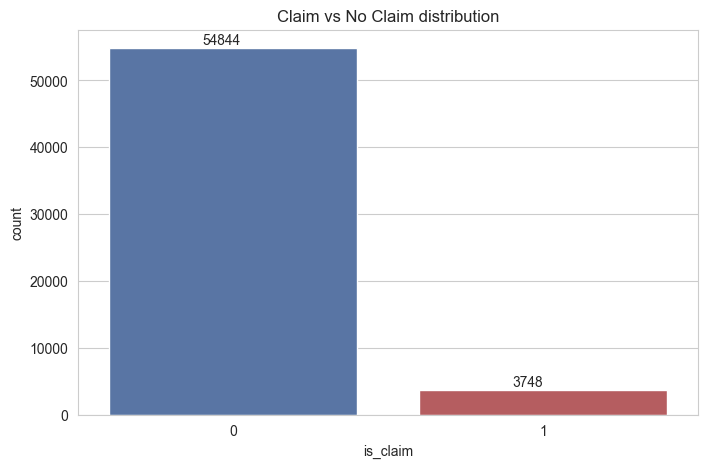

In [6]:
fig, ax = plt.subplots()
sns.countplot(x='is_claim', data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
ax.set_title('Claim vs No Claim distribution')
ax.set_xlabel('is_claim')
ax.set_ylabel('count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))
plt.show()

Only about 6.4% of policies resulted in a claim. This is a heavily imbalanced classification problem, so accuracy alone will be a misleading metric later - ROC-AUC and F1 are better choices, and class weights will be needed while training.

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('is_claim')
print('Numeric columns:', len(numeric_cols))
df[numeric_cols].describe().T

Numeric columns: 15


,count,mean,std,min,25%,50%,75%,max
policy_tenure,58592.0,0.611246,0.414156,0.002735,0.210250,0.573792,1.039104,1.396641
age_of_car,58592.0,0.069424,0.056721,0.000000,0.020000,0.060000,0.110000,1.000000
age_of_policyholder,58592.0,0.469420,0.122886,0.288462,0.365385,0.451923,0.548077,1.000000
population_density,58592.0,18826.858667,17660.174792,290.000000,6112.000000,8794.000000,27003.000000,73430.000000
make,58592.0,1.763722,1.136988,1.000000,1.000000,1.000000,3.000000,5.000000
airbags,58592.0,3.137066,1.832641,1.000000,2.000000,2.000000,6.000000,6.000000
displacement,58592.0,1162.355851,266.304786,796.000000,796.000000,1197.000000,1493.000000,1498.000000
cylinder,58592.0,3.626963,0.483616,3.000000,3.000000,4.000000,4.000000,4.000000
gear_box,58592.0,5.245443,0.430353,5.000000,5.000000,5.000000,5.000000,6.000000
turning_radius,58592.0,4.852893,0.228061,4.500000,4.600000,4.800000,5.000000,5.200000


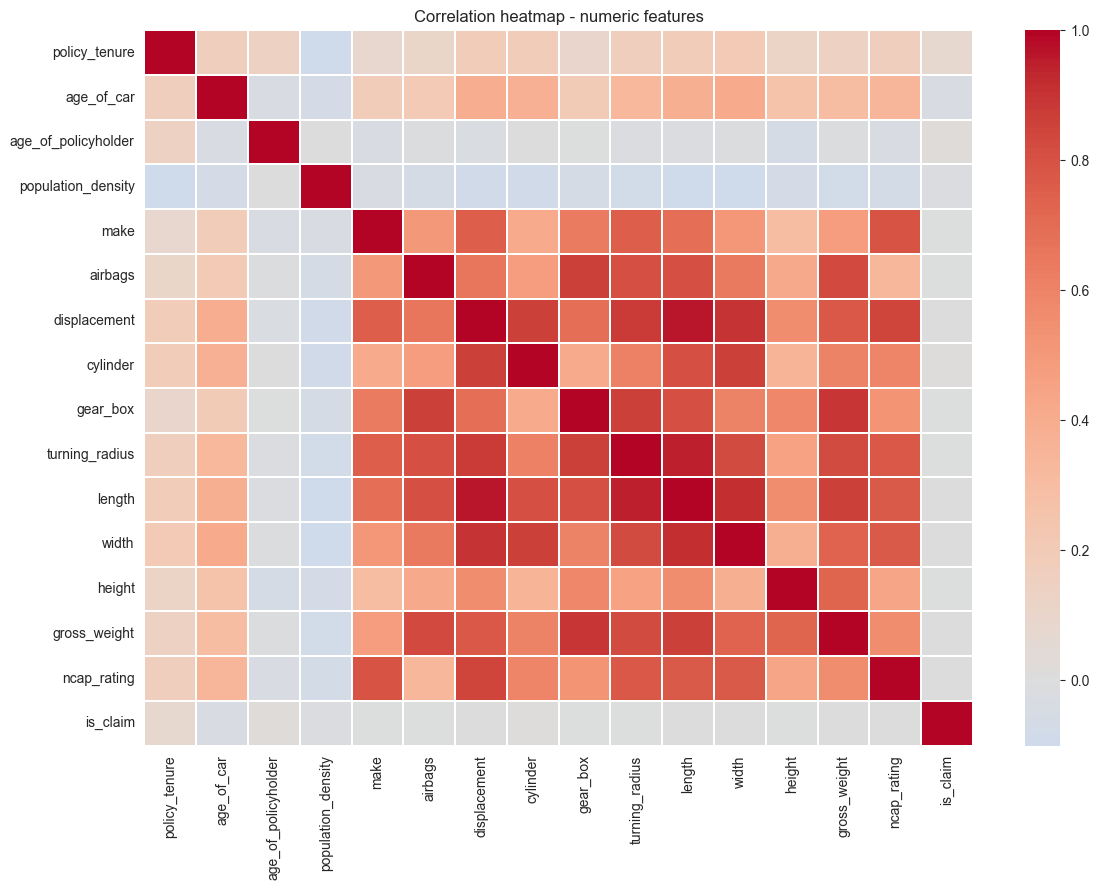

In [8]:
plt.figure(figsize=(12, 9))
corr = df[numeric_cols + ['is_claim']].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation heatmap - numeric features')
plt.tight_layout()
plt.show()

In [9]:
# correlation of every numeric feature with the target, sorted
target_corr = corr['is_claim'].drop('is_claim').sort_values(key=abs, ascending=False)
target_corr.head(10)

policy_tenure          0.078747
age_of_car            -0.028172
age_of_policyholder    0.022435
population_density    -0.017808
cylinder               0.013434
width                  0.009947
displacement           0.007678
length                 0.006495
gross_weight           0.003894
ncap_rating            0.003800
Name: is_claim, dtype: float64

None of the numeric features correlate strongly with the target on their own, which is expected for insurance claim data - claims usually depend on a combination of factors rather than a single strong driver.

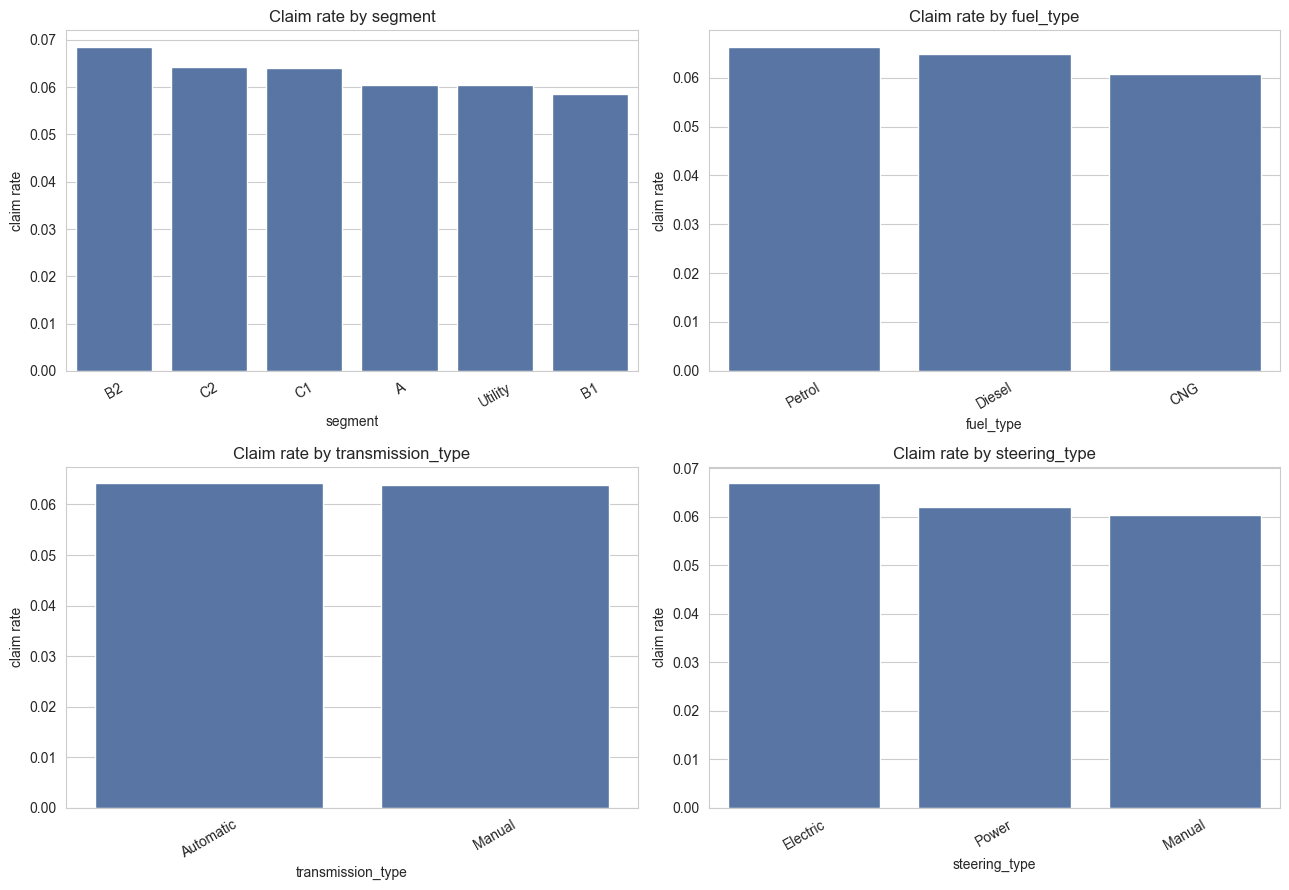

In [10]:
cat_cols = ['segment', 'fuel_type', 'transmission_type', 'steering_type']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, ax in zip(cat_cols, axes.flatten()):
    claim_rate = df.groupby(col)['is_claim'].mean().sort_values(ascending=False)
    sns.barplot(x=claim_rate.index, y=claim_rate.values, ax=ax, color='#4C72B0')
    ax.set_title(f'Claim rate by {col}')
    ax.set_ylabel('claim rate')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Claim rate does shift a bit across segments and fuel types, though the differences are not huge - again pointing towards a problem where many weak signals combine rather than one dominant feature.

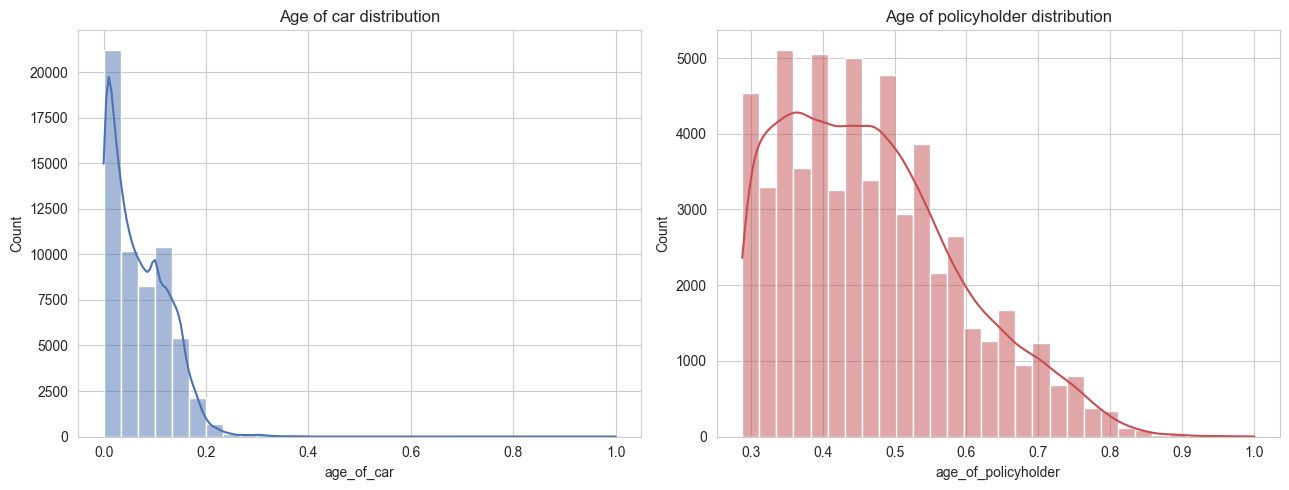

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['age_of_car'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age of car distribution')
sns.histplot(df['age_of_policyholder'], bins=30, kde=True, ax=axes[1], color='#C44E52')
axes[1].set_title('Age of policyholder distribution')
plt.tight_layout()
plt.show()

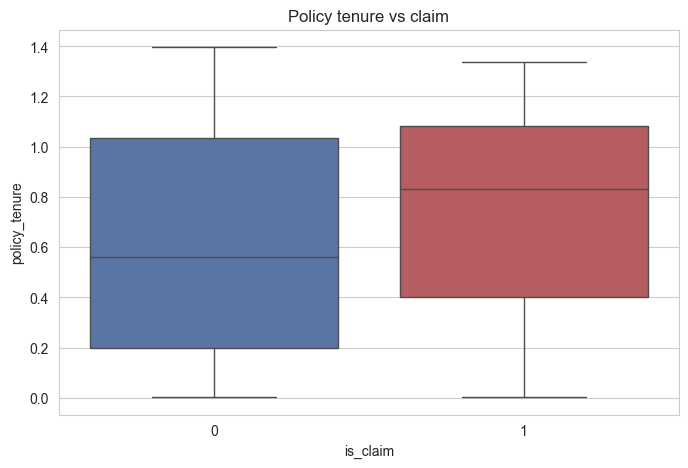

In [12]:
fig, ax = plt.subplots()
sns.boxplot(x='is_claim', y='policy_tenure', data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
ax.set_title('Policy tenure vs claim')
plt.show()

In [13]:
# quick check on the two combined string columns that will need
# splitting before modeling
print(df['max_torque'].unique())
print(df['max_power'].unique())

['60Nm@3500rpm' '113Nm@4400rpm' '91Nm@4250rpm' '250Nm@2750rpm'
 '200Nm@3000rpm' '82.1Nm@3400rpm' '200Nm@1750rpm' '85Nm@3000rpm'
 '170Nm@4000rpm']
['40.36bhp@6000rpm' '88.50bhp@6000rpm' '67.06bhp@5500rpm'
 '113.45bhp@4000rpm' '88.77bhp@4000rpm' '55.92bhp@5300rpm'
 '97.89bhp@3600rpm' '61.68bhp@6000rpm' '118.36bhp@5500rpm']


## Summary of findings

- Dataset is clean, no missing values anywhere.
- Target is heavily imbalanced (~6.4% claims), so ROC-AUC and F1 will be tracked instead of plain accuracy.
- `max_torque` and `max_power` are combined string columns and need to be split into numeric features.
- Several Yes/No flag columns exist and need binary encoding.
- No single numeric feature is strongly correlated with the target, so feature engineering and a model that can capture interactions (tree based) will matter more than a linear model.

Next notebook: `02_feature_engineering.ipynb`